In [3]:
import os
import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
from scipy import optimize
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from sklearn import metrics, ensemble, neighbors

In [15]:
print(pd.__version__)

3.0.2


In [4]:
training_df = pd.read_csv('data/training.csv')
testing_df = pd.read_csv('data/testing.csv')
validation_df = pd.read_csv('data/validation.csv')

# векторы признаков
X_train = training_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_test = testing_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_valid = validation_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)

X_train_valid = pd.concat([X_train, X_valid], ignore_index=False)

# векторы ответов
y_train = training_df['label']
y_test = testing_df['label']
y_valid = validation_df['label']

y_train_valid = pd.concat([y_train, y_valid], ignore_index=False)

norm_training_df = pd.read_csv('data/for-norm_training.csv')
norm_testing_df = pd.read_csv('data/for-norm_testing.csv')
norm_validation_df = pd.read_csv('data/for-norm_validation.csv')

X_norm_training = norm_training_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_testing = norm_testing_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_validation = norm_validation_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

X_norm_train_valid = pd.concat([X_norm_training, X_norm_validation], ignore_index=False)

y_norm_training = norm_training_df['label']
y_norm_testing = norm_testing_df['label']
y_norm_validation = norm_validation_df['label']

y_norm_train_valid = pd.concat([y_norm_training, y_norm_validation], ignore_index=False)


sec_train = pd.read_csv('data/for-2sec_training.csv')
sec_test = pd.read_csv('data/for-2sec_testing.csv')
sec_valid = pd.read_csv('data/for-2sec_validation.csv')


X_sec_train = sec_train.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_test = sec_test.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_valid = sec_valid.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

X_sec_train_valid = pd.concat([X_sec_train, X_sec_valid], ignore_index=False)

y_sec_train = sec_train['label']
y_sec_test = sec_test['label']
y_sec_valid = sec_valid['label']

y_sec_train_valid = pd.concat([y_sec_train, y_sec_valid], ignore_index=False)

rerec_train_df = pd.read_csv('data/for-rerec_training.csv')
rerec_test_df = pd.read_csv('data/for-rerec_testing.csv')
rerec_valid_df = pd.read_csv('data/for-rerec_validation.csv')

X_rerec_train = rerec_train_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_test = rerec_test_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_valid = rerec_valid_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)

X_rerec_train_valid = pd.concat([X_rerec_train, X_rerec_valid], ignore_index=False)

y_rerec_train = rerec_train_df['label']
y_rerec_test = rerec_test_df['label']
y_rerec_valid = rerec_valid_df['label']

y_rerec_train_valid = pd.concat([y_rerec_train, y_rerec_valid], ignore_index=False)


In [8]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 53868 entries, 0 to 53867
Data columns (total 56 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mfcc_0_mean     53868 non-null  float64
 1   mfcc_0_std      53868 non-null  float64
 2   mfcc_1_mean     53868 non-null  float64
 3   mfcc_1_std      53868 non-null  float64
 4   mfcc_2_mean     53868 non-null  float64
 5   mfcc_2_std      53868 non-null  float64
 6   mfcc_3_mean     53868 non-null  float64
 7   mfcc_3_std      53868 non-null  float64
 8   mfcc_4_mean     53868 non-null  float64
 9   mfcc_4_std      53868 non-null  float64
 10  mfcc_5_mean     53868 non-null  float64
 11  mfcc_5_std      53868 non-null  float64
 12  mfcc_6_mean     53868 non-null  float64
 13  mfcc_6_std      53868 non-null  float64
 14  mfcc_7_mean     53868 non-null  float64
 15  mfcc_7_std      53868 non-null  float64
 16  mfcc_8_mean     53868 non-null  float64
 17  mfcc_8_std      53868 non-null  float64
 1

In [5]:
datasets = {
    "original":(X_train, X_valid, y_train, y_valid),
    "norm":(X_norm_training, X_norm_validation,  y_norm_training, y_norm_validation),
    "sec":(X_sec_train, X_sec_test, y_sec_train, y_sec_test),
    "rerec":(X_rerec_train, X_rerec_test,  y_rerec_train, y_rerec_test),
}

In [6]:
def caluculate_eer(y_true, y_score):
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score, pos_label=1)

    eer = optimize.brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

    thresh = interp1d(fpr, thresholds)(eer)

    return eer, thresh

In [7]:
# Оптимизация гиперпараметров RF-моделей со всеми признаками
def create_objective(X_tr, X_valid, y_tr, y_valid):

    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 5, 100)
        max_depth = trial.suggest_int('max_depth', 1, 25)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)

        clf = ensemble.RandomForestClassifier(
            n_estimators=n_estimators,
            criterion='entropy',
            max_depth=max_depth,
            max_features='sqrt',
            min_samples_leaf=min_samples_leaf
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_valid)[:, 1]

        eer, best_threshold = caluculate_eer(y_valid, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_valid, y_score > 0.5))


        # y_pred_valid = clf.predict(X_test)
        
        # score = metrics.accuracy_score(y_test, y_pred_test)

        return eer
    return objective



In [177]:
db_url = "sqlite:///RF_full.db"
for name, (X_tr, X_valid, y_tr, y_valid) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"rf_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_valid, y_tr, y_valid)

    study.optimize(obj_func, n_trials=100)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-03-23 16:39:31,518] A new study created in RDB with name: rf_original
[I 2026-03-23 16:39:35,146] Trial 0 finished with value: 0.0040611688758367065 and parameters: {'n_estimators': 10, 'max_depth': 23, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.0040611688758367065.
[I 2026-03-23 16:39:51,395] Trial 1 finished with value: 0.002778806965873524 and parameters: {'n_estimators': 47, 'max_depth': 21, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.002778806965873524.
[I 2026-03-23 16:40:11,855] Trial 2 finished with value: 0.015190811411633956 and parameters: {'n_estimators': 95, 'max_depth': 6, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.002778806965873524.
[I 2026-03-23 16:40:36,416] Trial 3 finished with value: 0.0025935531678398798 and parameters: {'n_estimators': 72, 'max_depth': 18, 'min_samples_leaf': 4}. Best is trial 3 with value: 0.0025935531678398798.
[I 2026-03-23 16:40:43,682] Trial 4 finished with value: 0.0031481481481151017 and parameters: 

Лучшие параметры для original: {'n_estimators': 84, 'max_depth': 16, 'min_samples_leaf': 1} с показателем EER: 0.0016666666670036951

>>> Запуск оптимизации для датасета: norm


[I 2026-03-23 17:20:30,387] A new study created in RDB with name: rf_norm
[I 2026-03-23 17:20:38,672] Trial 0 finished with value: 0.012592592592063388 and parameters: {'n_estimators': 21, 'max_depth': 21, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.012592592592063388.
[I 2026-03-23 17:21:02,184] Trial 1 finished with value: 0.010372565622355235 and parameters: {'n_estimators': 58, 'max_depth': 20, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.010372565622355235.
[I 2026-03-23 17:21:27,342] Trial 2 finished with value: 0.011111111110165196 and parameters: {'n_estimators': 65, 'max_depth': 15, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.010372565622355235.
[I 2026-03-23 17:21:54,680] Trial 3 finished with value: 0.009168364511946667 and parameters: {'n_estimators': 68, 'max_depth': 22, 'min_samples_leaf': 1}. Best is trial 3 with value: 0.009168364511946667.
[I 2026-03-23 17:22:13,499] Trial 4 finished with value: 0.025750277880697045 and parameters: {'n_esti

Лучшие параметры для norm: {'n_estimators': 68, 'max_depth': 24, 'min_samples_leaf': 1} с показателем EER: 0.008863371785374096

>>> Запуск оптимизации для датасета: sec


[I 2026-03-23 18:03:03,422] A new study created in RDB with name: rf_sec
[I 2026-03-23 18:03:04,621] Trial 0 finished with value: 0.4889705882354485 and parameters: {'n_estimators': 15, 'max_depth': 8, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.4889705882354485.
[I 2026-03-23 18:03:06,767] Trial 1 finished with value: 0.5330882352929489 and parameters: {'n_estimators': 57, 'max_depth': 3, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.4889705882354485.
[I 2026-03-23 18:03:12,327] Trial 2 finished with value: 0.527573529412656 and parameters: {'n_estimators': 65, 'max_depth': 11, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.4889705882354485.
[I 2026-03-23 18:03:15,590] Trial 3 finished with value: 0.5575200534763868 and parameters: {'n_estimators': 34, 'max_depth': 24, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.4889705882354485.
[I 2026-03-23 18:03:19,810] Trial 4 finished with value: 0.551470588235294 and parameters: {'n_estimators': 58, 'max_depth

Лучшие параметры для sec: {'n_estimators': 10, 'max_depth': 1, 'min_samples_leaf': 1} с показателем EER: 0.34878780521642616

>>> Запуск оптимизации для датасета: rerec


[I 2026-03-23 18:05:46,351] A new study created in RDB with name: rf_rerec
[I 2026-03-23 18:05:50,027] Trial 0 finished with value: 0.4436274509798415 and parameters: {'n_estimators': 60, 'max_depth': 16, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.4436274509798415.
[I 2026-03-23 18:05:51,022] Trial 1 finished with value: 0.4460784313730486 and parameters: {'n_estimators': 15, 'max_depth': 17, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.4436274509798415.
[I 2026-03-23 18:05:54,225] Trial 2 finished with value: 0.4632352941176468 and parameters: {'n_estimators': 60, 'max_depth': 9, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.4436274509798415.
[I 2026-03-23 18:05:56,122] Trial 3 finished with value: 0.4387254901962428 and parameters: {'n_estimators': 90, 'max_depth': 3, 'min_samples_leaf': 5}. Best is trial 3 with value: 0.4387254901962428.
[I 2026-03-23 18:05:57,246] Trial 4 finished with value: 0.48125720876584577 and parameters: {'n_estimators': 17, 'max_

Лучшие параметры для rerec: {'n_estimators': 95, 'max_depth': 1, 'min_samples_leaf': 5} с показателем EER: 0.32352941176472394


In [178]:
# Оптимизация гиперпараметров XGB-моделей
def create_objective(X_tr, X_valid, y_tr, y_valid):

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'gamma': trial.suggest_float('gamma', 1e-8, 0.5, log=True),
            'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
            'subsample':trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42
        }

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_valid)[:, 1]

        eer, best_threshold = caluculate_eer(y_valid, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_valid, y_score > 0.5))

        return eer
    
    return objective

In [179]:
db_url = "sqlite:///XGB_research.db"
for name, (X_tr, X_valid, y_tr, y_valid) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"xgb_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_valid, y_tr, y_valid)

    study.optimize(obj_func, n_trials=100)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-03-23 18:09:24,347] A new study created in RDB with name: xgb_original
[I 2026-03-23 18:09:25,664] Trial 0 finished with value: 0.0007407407409660599 and parameters: {'n_estimators': 379, 'learning_rate': 0.10995584162627735, 'max_depth': 4, 'gamma': 6.728389762345141e-05, 'lambda': 1.3052540287542739e-05, 'alpha': 0.7434504668288544, 'subsample': 0.6278474181767475, 'colsample_bytree': 0.865873130250401}. Best is trial 0 with value: 0.0007407407409660599.
[I 2026-03-23 18:09:27,210] Trial 1 finished with value: 0.0007410151908113723 and parameters: {'n_estimators': 540, 'learning_rate': 0.08231802078676341, 'max_depth': 5, 'gamma': 0.3070617658468985, 'lambda': 0.13012786516055858, 'alpha': 0.05934969970502681, 'subsample': 0.6210136427141879, 'colsample_bytree': 0.8662240690013678}. Best is trial 0 with value: 0.0007407407409660599.
[I 2026-03-23 18:09:27,864] Trial 2 finished with value: 0.0007407407404246239 and parameters: {'n_estimators': 152, 'learning_rate': 0.269852964

Лучшие параметры для original: {'n_estimators': 381, 'learning_rate': 0.2190458957252609, 'max_depth': 3, 'gamma': 0.0007572513241975611, 'lambda': 8.950634136515791e-07, 'alpha': 0.008137352099432723, 'subsample': 0.7892582205726003, 'colsample_bytree': 0.8429428194222681} с показателем EER: 0.0005555555556560722

>>> Запуск оптимизации для датасета: norm


[I 2026-03-23 18:11:31,249] A new study created in RDB with name: xgb_norm
[I 2026-03-23 18:11:31,906] Trial 0 finished with value: 0.008706928491663839 and parameters: {'n_estimators': 110, 'learning_rate': 0.0846266696828713, 'max_depth': 5, 'gamma': 9.212775030604168e-07, 'lambda': 0.08787707916860672, 'alpha': 0.011622365267590735, 'subsample': 0.7591965622496772, 'colsample_bytree': 0.9070226081579026}. Best is trial 0 with value: 0.008706928491663839.
[I 2026-03-23 18:11:32,859] Trial 1 finished with value: 0.007962962961816191 and parameters: {'n_estimators': 189, 'learning_rate': 0.05859123481190038, 'max_depth': 5, 'gamma': 0.18057500178998298, 'lambda': 0.0822159778779818, 'alpha': 0.01807866558308021, 'subsample': 0.6156199228710979, 'colsample_bytree': 0.635965035252143}. Best is trial 1 with value: 0.007962962961816191.
[I 2026-03-23 18:11:34,886] Trial 2 finished with value: 0.005740740740097443 and parameters: {'n_estimators': 273, 'learning_rate': 0.03157356921762321, '

Лучшие параметры для norm: {'n_estimators': 325, 'learning_rate': 0.07412985650056074, 'max_depth': 8, 'gamma': 9.132087497228264e-07, 'lambda': 0.0948767089202964, 'alpha': 0.0013011052362112028, 'subsample': 0.6377460896000878, 'colsample_bytree': 0.7766372070405124} с показателем EER: 0.0029629629642153738

>>> Запуск оптимизации для датасета: sec


[I 2026-03-23 18:15:54,318] A new study created in RDB with name: xgb_sec
[I 2026-03-23 18:15:55,143] Trial 0 finished with value: 0.4908088235287291 and parameters: {'n_estimators': 392, 'learning_rate': 0.27157511696793313, 'max_depth': 9, 'gamma': 9.444435009161442e-08, 'lambda': 0.08862070051387679, 'alpha': 1.3400982945757345e-08, 'subsample': 0.9312833799574014, 'colsample_bytree': 0.896461413956136}. Best is trial 0 with value: 0.4908088235287291.
[I 2026-03-23 18:15:56,255] Trial 1 finished with value: 0.5220588235294118 and parameters: {'n_estimators': 435, 'learning_rate': 0.053573653876179336, 'max_depth': 5, 'gamma': 2.5445483760970736e-08, 'lambda': 0.017157777481681034, 'alpha': 0.005721885058382999, 'subsample': 0.6101210931085977, 'colsample_bytree': 0.9957696283764446}. Best is trial 0 with value: 0.4908088235287291.
[I 2026-03-23 18:15:57,731] Trial 2 finished with value: 0.5367647058823728 and parameters: {'n_estimators': 198, 'learning_rate': 0.06192139601950027, 'm

Лучшие параметры для sec: {'n_estimators': 505, 'learning_rate': 0.9839821796766377, 'max_depth': 4, 'gamma': 0.0001893429855388805, 'lambda': 0.05268681135750586, 'alpha': 2.7851170597730075e-07, 'subsample': 0.9778953740842745, 'colsample_bytree': 0.6169450509260864} с показателем EER: 0.3069852941165844

>>> Запуск оптимизации для датасета: rerec


[I 2026-03-23 18:17:24,207] A new study created in RDB with name: xgb_rerec
[I 2026-03-23 18:17:24,959] Trial 0 finished with value: 0.4166666666666538 and parameters: {'n_estimators': 379, 'learning_rate': 0.3594399991868188, 'max_depth': 7, 'gamma': 0.001326742151931013, 'lambda': 1.4147879461422919e-06, 'alpha': 8.60411229205277e-08, 'subsample': 0.6143875994373503, 'colsample_bytree': 0.9212436862641973}. Best is trial 0 with value: 0.4166666666666538.
[I 2026-03-23 18:17:25,816] Trial 1 finished with value: 0.44852941176411404 and parameters: {'n_estimators': 511, 'learning_rate': 0.3898801123795437, 'max_depth': 7, 'gamma': 0.00198800033297938, 'lambda': 3.826852967813007e-06, 'alpha': 0.07532294627118773, 'subsample': 0.6733840873927256, 'colsample_bytree': 0.8457344885756933}. Best is trial 0 with value: 0.4166666666666538.
[I 2026-03-23 18:17:26,886] Trial 2 finished with value: 0.4901960784307155 and parameters: {'n_estimators': 366, 'learning_rate': 0.16174949170573344, 'max

Лучшие параметры для rerec: {'n_estimators': 631, 'learning_rate': 0.9980949542081256, 'max_depth': 4, 'gamma': 0.008033843779854468, 'lambda': 0.0023963477675237018, 'alpha': 0.004803967673027555, 'subsample': 0.6794725983375932, 'colsample_bytree': 0.7674182352341854} с показателем EER: 0.3627450980392201


In [180]:
# Оптимизация гиперпараметров KNN-моделей
def create_objective(X_tr, X_valid, y_tr, y_valid):

    def objective(trial):
        
        n_neighbors = trial.suggest_int('n_neighbors', 2, 60)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        leaf_size = trial.suggest_int('leaf_size', 10, 50)
        p = trial.suggest_int('p', 1, 2)

        clf = neighbors.KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            leaf_size=leaf_size,
            p=p,
            n_jobs=-1
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_valid)[:, 1]

        eer, best_threshold = caluculate_eer(y_valid, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_valid, y_score > 0.5))

        return eer
    
    return objective

In [181]:
db_url = "sqlite:///knn_research.db"
for name, (X_tr, X_valid, y_tr, y_valid) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"knn_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_valid, y_tr, y_valid)

    study.optimize(obj_func, n_trials=100)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-03-23 18:18:48,134] A new study created in RDB with name: knn_original
[I 2026-03-23 18:18:51,257] Trial 0 finished with value: 0.03919389493961619 and parameters: {'n_neighbors': 41, 'weights': 'uniform', 'leaf_size': 40, 'p': 1}. Best is trial 0 with value: 0.03919389493961619.
[I 2026-03-23 18:18:51,909] Trial 1 finished with value: 0.08388888888904694 and parameters: {'n_neighbors': 45, 'weights': 'distance', 'leaf_size': 14, 'p': 2}. Best is trial 0 with value: 0.03919389493961619.
[I 2026-03-23 18:18:54,975] Trial 2 finished with value: 0.03575023554327953 and parameters: {'n_neighbors': 30, 'weights': 'uniform', 'leaf_size': 40, 'p': 1}. Best is trial 2 with value: 0.03575023554327953.
[I 2026-03-23 18:18:57,970] Trial 3 finished with value: 0.033371789036949234 and parameters: {'n_neighbors': 21, 'weights': 'uniform', 'leaf_size': 49, 'p': 1}. Best is trial 3 with value: 0.033371789036949234.
[I 2026-03-23 18:18:58,617] Trial 4 finished with value: 0.09148148148167157 a

Лучшие параметры для original: {'n_neighbors': 2, 'weights': 'distance', 'leaf_size': 36, 'p': 1} с показателем EER: 0.02055555555585749

>>> Запуск оптимизации для датасета: norm


[I 2026-03-23 18:23:58,574] A new study created in RDB with name: knn_norm
[I 2026-03-23 18:23:59,259] Trial 0 finished with value: 0.174727097199357 and parameters: {'n_neighbors': 21, 'weights': 'uniform', 'leaf_size': 37, 'p': 2}. Best is trial 0 with value: 0.174727097199357.
[I 2026-03-23 18:23:59,977] Trial 1 finished with value: 0.17170857398890613 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'leaf_size': 37, 'p': 2}. Best is trial 1 with value: 0.17170857398890613.
[I 2026-03-23 18:24:00,734] Trial 2 finished with value: 0.18739317030835745 and parameters: {'n_neighbors': 33, 'weights': 'uniform', 'leaf_size': 47, 'p': 2}. Best is trial 1 with value: 0.17170857398890613.
[I 2026-03-23 18:24:04,043] Trial 3 finished with value: 0.07375243274285806 and parameters: {'n_neighbors': 20, 'weights': 'uniform', 'leaf_size': 32, 'p': 1}. Best is trial 3 with value: 0.07375243274285806.
[I 2026-03-23 18:24:04,732] Trial 4 finished with value: 0.157777777776832 and parameters

Лучшие параметры для norm: {'n_neighbors': 5, 'weights': 'distance', 'leaf_size': 13, 'p': 1} с показателем EER: 0.05724342349017153

>>> Запуск оптимизации для датасета: sec


[I 2026-03-23 18:29:08,244] A new study created in RDB with name: knn_sec
[I 2026-03-23 18:29:08,438] Trial 0 finished with value: 0.4946512459150327 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'leaf_size': 11, 'p': 1}. Best is trial 0 with value: 0.4946512459150327.
[I 2026-03-23 18:29:08,623] Trial 1 finished with value: 0.47610294117730023 and parameters: {'n_neighbors': 28, 'weights': 'distance', 'leaf_size': 36, 'p': 1}. Best is trial 1 with value: 0.47610294117730023.
[I 2026-03-23 18:29:08,727] Trial 2 finished with value: 0.45772058823529377 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'leaf_size': 28, 'p': 2}. Best is trial 2 with value: 0.45772058823529377.
[I 2026-03-23 18:29:08,849] Trial 3 finished with value: 0.4015566332916145 and parameters: {'n_neighbors': 57, 'weights': 'uniform', 'leaf_size': 18, 'p': 2}. Best is trial 3 with value: 0.4015566332916145.
[I 2026-03-23 18:29:09,021] Trial 4 finished with value: 0.4963235294117648 and paramete

Лучшие параметры для sec: {'n_neighbors': 57, 'weights': 'distance', 'leaf_size': 44, 'p': 2} с показателем EER: 0.3952205882352941

>>> Запуск оптимизации для датасета: rerec


[I 2026-03-23 18:29:20,864] A new study created in RDB with name: knn_rerec
[I 2026-03-23 18:29:20,999] Trial 0 finished with value: 0.38725490196079976 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'leaf_size': 17, 'p': 1}. Best is trial 0 with value: 0.38725490196079976.
[I 2026-03-23 18:29:21,127] Trial 1 finished with value: 0.39144528779253634 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'leaf_size': 50, 'p': 1}. Best is trial 0 with value: 0.38725490196079976.
[I 2026-03-23 18:29:21,223] Trial 2 finished with value: 0.38242953431372545 and parameters: {'n_neighbors': 48, 'weights': 'uniform', 'leaf_size': 49, 'p': 2}. Best is trial 2 with value: 0.38242953431372545.
[I 2026-03-23 18:29:21,324] Trial 3 finished with value: 0.382397504456328 and parameters: {'n_neighbors': 46, 'weights': 'uniform', 'leaf_size': 39, 'p': 2}. Best is trial 3 with value: 0.382397504456328.
[I 2026-03-23 18:29:21,419] Trial 4 finished with value: 0.39705882352941096 and parame

Лучшие параметры для rerec: {'n_neighbors': 45, 'weights': 'distance', 'leaf_size': 17, 'p': 1} с показателем EER: 0.3627450980391222


In [182]:
# CONFUSION MATRIX
# WITH PROBABILITY THRESHOLD

# RF

In [ ]:
def test_objective(X_tr, X_test, y_tr, y_test):

        clf = ensemble.RandomForestClassifier(
            n_estimators=95,
            criterion='entropy',
            max_depth=19,
            max_features='sqrt',
            min_samples_leaf=1
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_test)[:, 1]

        y_score = pd.Series(y_score)

        eer, best_threshold = caluculate_eer(y_test, y_score)

        # y_pred_prob_test = clf.predict_proba(X_test)

        recall_scores=[]
        precision_scores=[]
        f1_scores=[]

        thresholds = np.arange(0.1, 1, 0.05)

        for threshold in thresholds:
            y_pred = y_score.apply(lambda x: 1 if x > threshold else 0)
            # считаем метрики и добавляем их в списки
            recall_scores.append(metrics.recall_score(y_test, y_pred))
            precision_scores.append(metrics.precision_score(y_test, y_pred))
            f1_scores.append(metrics.f1_score(y_test, y_pred))

        # Визуализируем метрики при различных threshold
        fig, ax = plt.subplots(figsize=(10, 4)) # фигура + координатная плоскость
        # строим линейный график зависимости recall от threshold
        ax.plot(thresholds, recall_scores, label='Recall')
        # строим линейный график зависимости precision от threshold
        ax.plot(thresholds, precision_scores, label='Precision')
        # строим линейны график зависимости f1 от threshold
        ax.plot(thresholds, f1_scores, label='F1-score')

        # даем графику название и подписываем оси
        ax.set_title('Recall/Precision/F1 dependence on the threshold')
        ax.set_xlabel('Probability threshold')
        ax.set_ylabel('Score')
        # Устанавливаем отметки по оси x
        ax.set_xticks(thresholds);
        # отображаем легенду
        ax.legend();

        fig.show();
        
        # score = metrics.accuracy_score(y_test, y_pred_test)

        

>>>original


C:\Users\Kirill\AppData\Local\Temp\ipykernel_2852\1916002762.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show();


>>>norm


C:\Users\Kirill\AppData\Local\Temp\ipykernel_2852\1916002762.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show();


>>>sec


c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\s

>>>rerec


c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\s

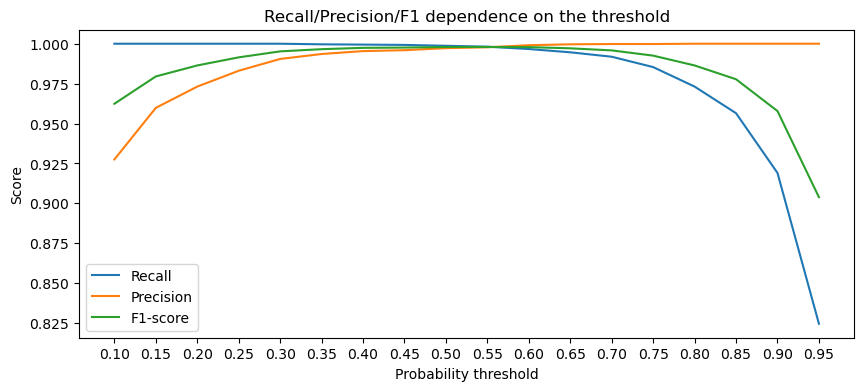

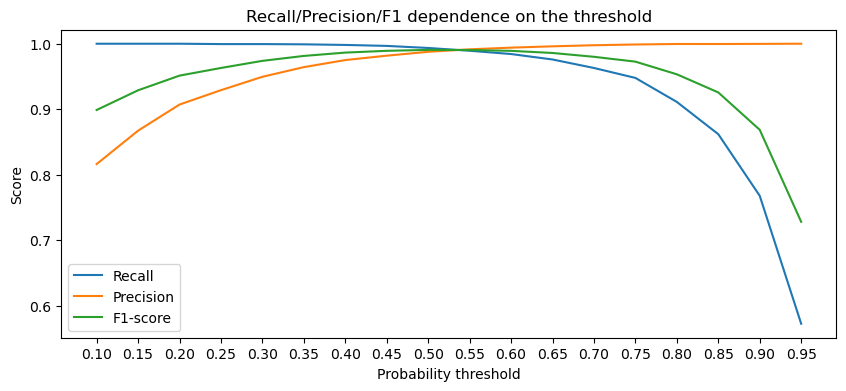

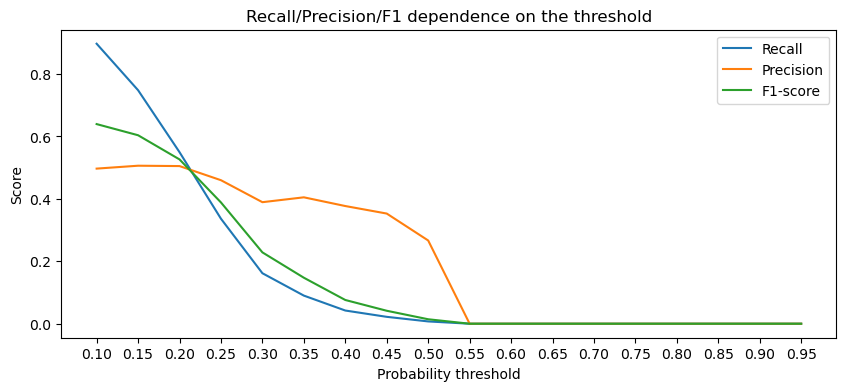

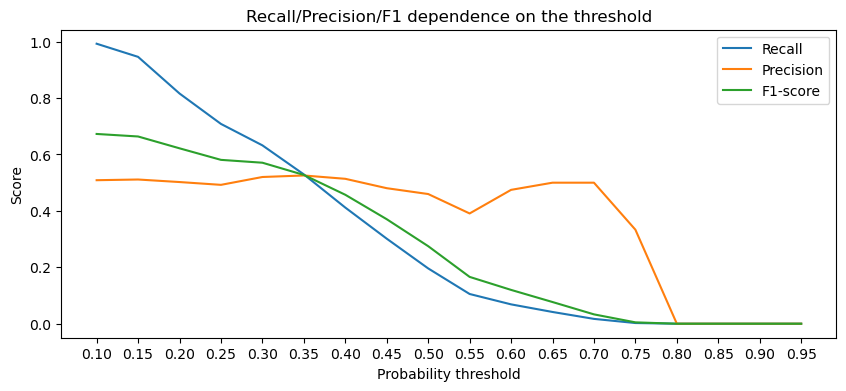

In [184]:
for name, (X_tr, X_test, y_tr, y_test) in datasets.items():
    print(f">>>{name}")
    
    test_objective(X_tr, X_test, y_tr, y_test)

In [66]:
training_df = pd.read_csv('data/training.csv')
testing_df = pd.read_csv('data/testing.csv')
validation_df = pd.read_csv('data/validation.csv')

# векторы признаков
X_train = training_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_test = testing_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_valid = validation_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)

X_train = X_train[['spec_cent_mean', 'spec_cent_std', 'roloff_mean']]
X_test = X_test[['spec_cent_mean', 'spec_cent_std', 'roloff_mean']]
X_valid = X_valid[['spec_cent_mean', 'spec_cent_std', 'roloff_mean']]

X_train_valid = pd.concat([X_train, X_valid], ignore_index=False)

# векторы ответов
y_train = training_df['label']
y_test = testing_df['label']
y_valid = validation_df['label']

y_train_valid = pd.concat([y_train, y_valid], ignore_index=False)

norm_training_df = pd.read_csv('data/for-norm_training.csv')
norm_testing_df = pd.read_csv('data/for-norm_testing.csv')
norm_validation_df = pd.read_csv('data/for-norm_validation.csv')

X_norm_training = norm_training_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_testing = norm_testing_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_validation = norm_validation_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

X_norm_train_valid = pd.concat([X_norm_training, X_norm_validation], ignore_index=False)

y_norm_training = norm_training_df['label']
y_norm_testing = norm_testing_df['label']
y_norm_validation = norm_validation_df['label']

y_norm_train_valid = pd.concat([y_norm_training, y_norm_validation], ignore_index=False)


sec_train = pd.read_csv('data/for-2sec_training.csv')
sec_test = pd.read_csv('data/for-2sec_testing.csv')
sec_valid = pd.read_csv('data/for-2sec_validation.csv')


X_sec_train = sec_train.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_test = sec_test.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_valid = sec_valid.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

X_sec_train_valid = pd.concat([X_sec_train, X_sec_valid], ignore_index=False)

y_sec_train = sec_train['label']
y_sec_test = sec_test['label']
y_sec_valid = sec_valid['label']

y_sec_train_valid = pd.concat([y_sec_train, y_sec_valid], ignore_index=False)

rerec_train_df = pd.read_csv('data/for-rerec_training.csv')
rerec_test_df = pd.read_csv('data/for-rerec_testing.csv')
rerec_valid_df = pd.read_csv('data/for-rerec_validation.csv')

X_rerec_train = rerec_train_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_test = rerec_test_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_valid = rerec_valid_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)

X_rerec_train_valid = pd.concat([X_rerec_train, X_rerec_valid], ignore_index=False)

y_rerec_train = rerec_train_df['label']
y_rerec_test = rerec_test_df['label']
y_rerec_valid = rerec_valid_df['label']

y_rerec_train_valid = pd.concat([y_rerec_train, y_rerec_valid], ignore_index=False)


In [12]:
datasets = {
    'original': {'train': (X_train_valid, y_train_valid) , 'test': (X_test, y_test)},
    'norm': {'train': (X_norm_train_valid, y_norm_train_valid), 'test': (X_norm_testing, y_norm_testing)},
    '2sec': {'train': (X_sec_train_valid, y_sec_train_valid), 'test': (X_sec_test, y_sec_test) },
    'rerec': {'train': (X_rerec_train_valid, y_rerec_train_valid), 'test': (X_rerec_test, y_rerec_test)}
}

In [68]:
rf_best_params = {
    'original': {'max_depth': 16, 'min_samples_leaf': 1, 'n_estimators': 84 } ,
    'norm': {'max_depth': 14, 'min_samples_leaf': 1, 'n_estimators': 79 },
    '2sec': {'max_depth': 25, 'min_samples_leaf': 1, 'n_estimators': 48 },
    'rerec': {'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 10 },
}

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

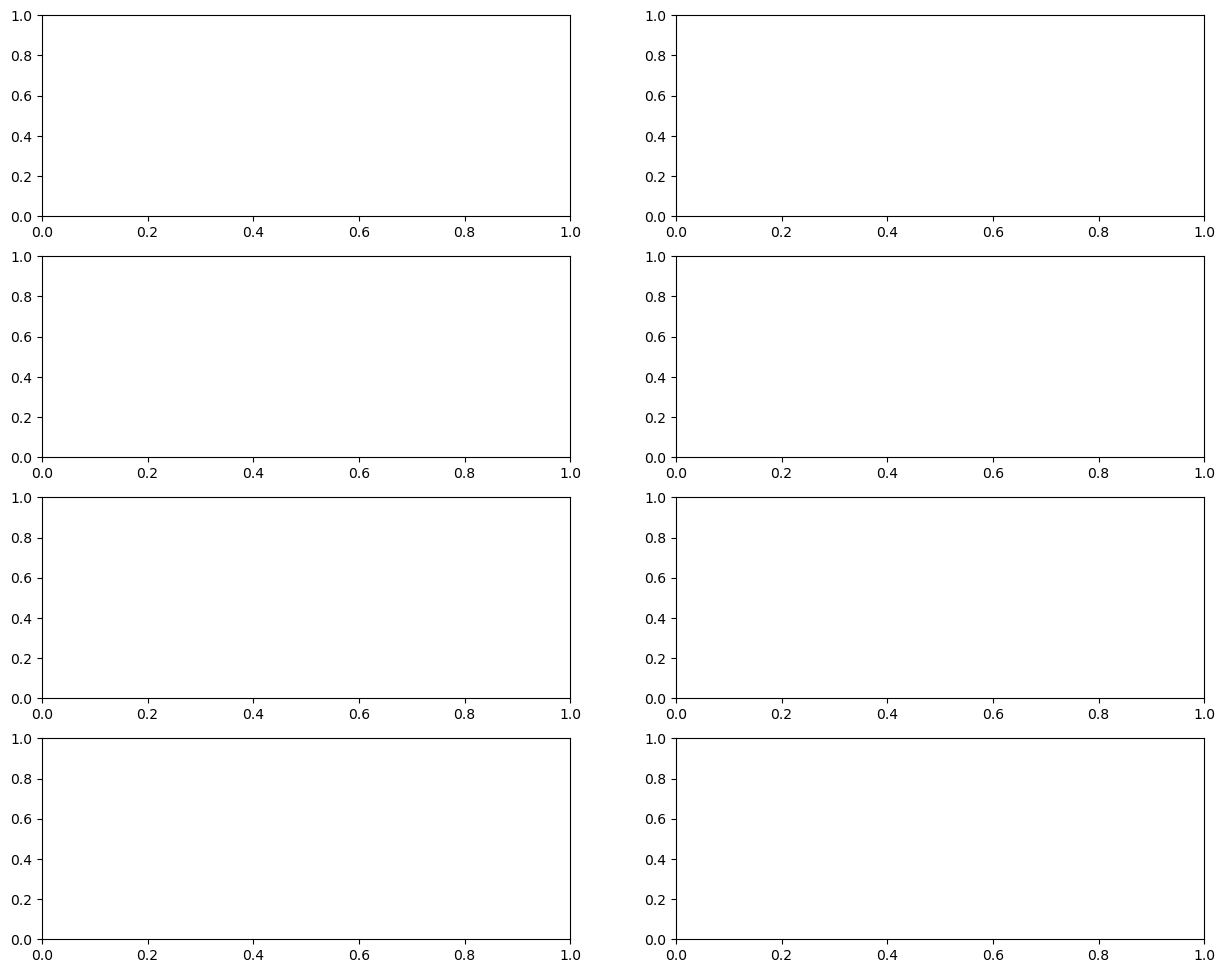

In [69]:
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(4,2, figsize=(15,12))

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = rf_best_params[name]
    
    # Инициализация и обучение модели
    model = ensemble.RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
            # Если вероятность > threshold, то 1, иначе 0
            y_pred_custom = (y_score > threshold).astype(int)
            
            recall_scores.append(metrics.recall_score(y_test, y_pred_custom))
            precision_scores.append(metrics.precision_score(y_test, y_pred_custom))
            f1_scores.append(metrics.f1_score(y_test, y_pred_custom))

    # 5. Визуализация на i-м графике
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') # Выделим F1 пожирнее

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) # Сетка чуть пореже для читаемости
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()
    
    

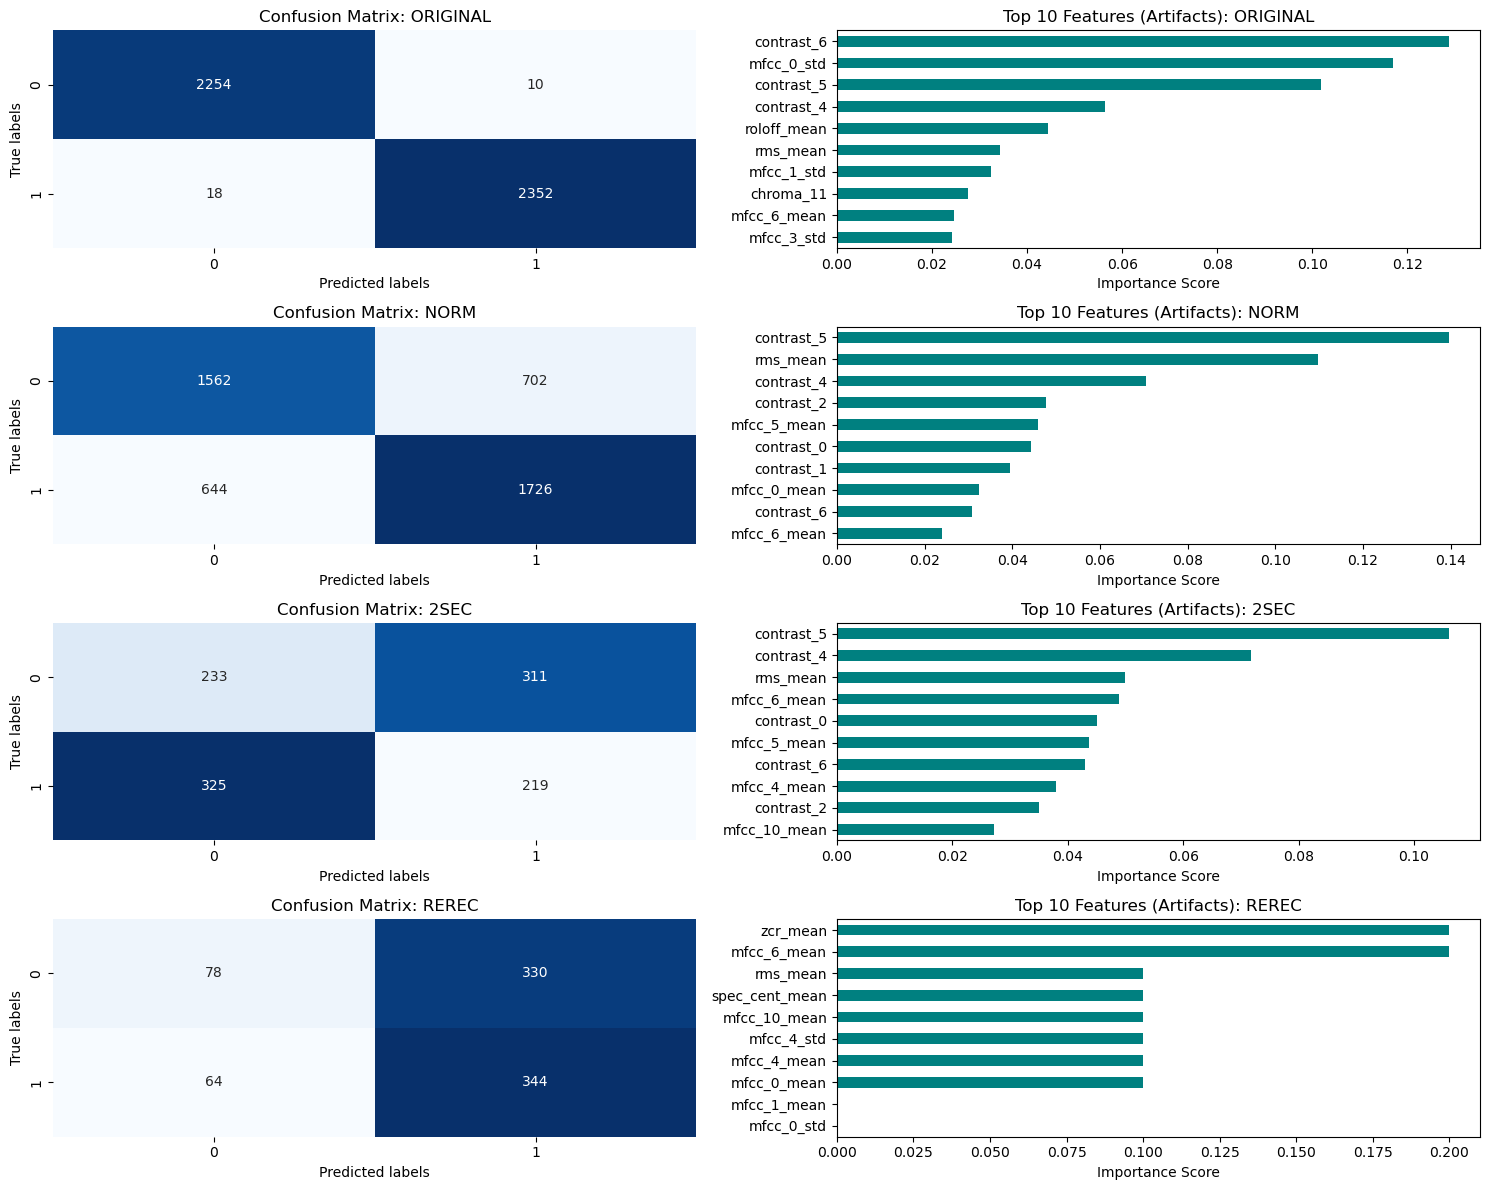


--- Итоговые результаты по всем датасетам ---
    Dataset       EER  Accuracy  F1-Score  Precision    Recall
0  original  0.005485  0.993958  0.994083   0.995766  0.992405
1      norm  0.296203  0.709538  0.719466   0.710873  0.728270
2      2sec  0.580798  0.415441  0.407821   0.413208  0.402574
3     rerec  0.438881  0.517157  0.635860   0.510386  0.843137


In [218]:
final_metrics = []

custom_thresholds = {
      'original': 0.25,
      'norm': 0.31,
      '2sec': 0.21,
      'rerec': 0.45, 
}

fig, axes = plt.subplots(4,2, figsize=(15,12))
# axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = rf_best_params[name]
    
    # Инициализация и обучение модели
    model = ensemble.RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i, 0], cmap='Blues', cbar=False)
    axes[i, 0].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i, 0].set_xlabel('Predicted labels')
    axes[i, 0].set_ylabel('True labels')

    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[i, 1], color='teal')
    axes[i, 1].set_title(f"Top 10 Features (Artifacts): {name.upper()}", fontsize=12)
    axes[i, 1].set_xlabel('Importance Score')

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
df_results.to_excel('results/research1_rf_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)

In [219]:
xgb_best_params = {
    'original': {
        'n_estimators':  381,
        'learning_rate': 0.2190458957252609	,
        'max_depth': 1,
        'gamma': 0.0007572513241975611,
        'lambda': 8.950634136515791e-7,
        'alpha': 0.008137352099432723,
        'subsample': 0.7892582205726003	,
        'colsample_bytree': 0.8429428194222681	,
        'random_state': 42
    },
    'norm': {
        'n_estimators':  325,
        'learning_rate': 0.07412985650056074,
        'max_depth': 1,
        'gamma': 9.132087497228264e-7,
        'lambda': 0.0948767089202964,
        'alpha': 0.0013011052362112028,
        'subsample': 0.6377460896000878,
        'colsample_bytree': 0.7766372070405124,
        'random_state': 42
    },
    '2sec': {
        'n_estimators':  5,
        'learning_rate': 0.1839821796766377,
        'max_depth': 10,
        'gamma': 0.0001893429855388805,
        'lambda': 0.05268681135750586,
        'alpha': 2.7851170597730075e-7,
        'subsample': 0.9778953740842745,
        'colsample_bytree': 0.6169450509260864,
        'random_state': 42
    },
    'rerec': {
        'n_estimators':  6531,
        'learning_rate': 0.0980949542081256,
        'max_depth': 1,
        'gamma': 0.008033843779854468,
        'lambda': 0.0023963477675237018,
        'alpha': 0.004803967673027555,
        'subsample': 0.6794725983375932,
        'colsample_bytree':0.7674182352341854,
        'random_state': 42
    },
}

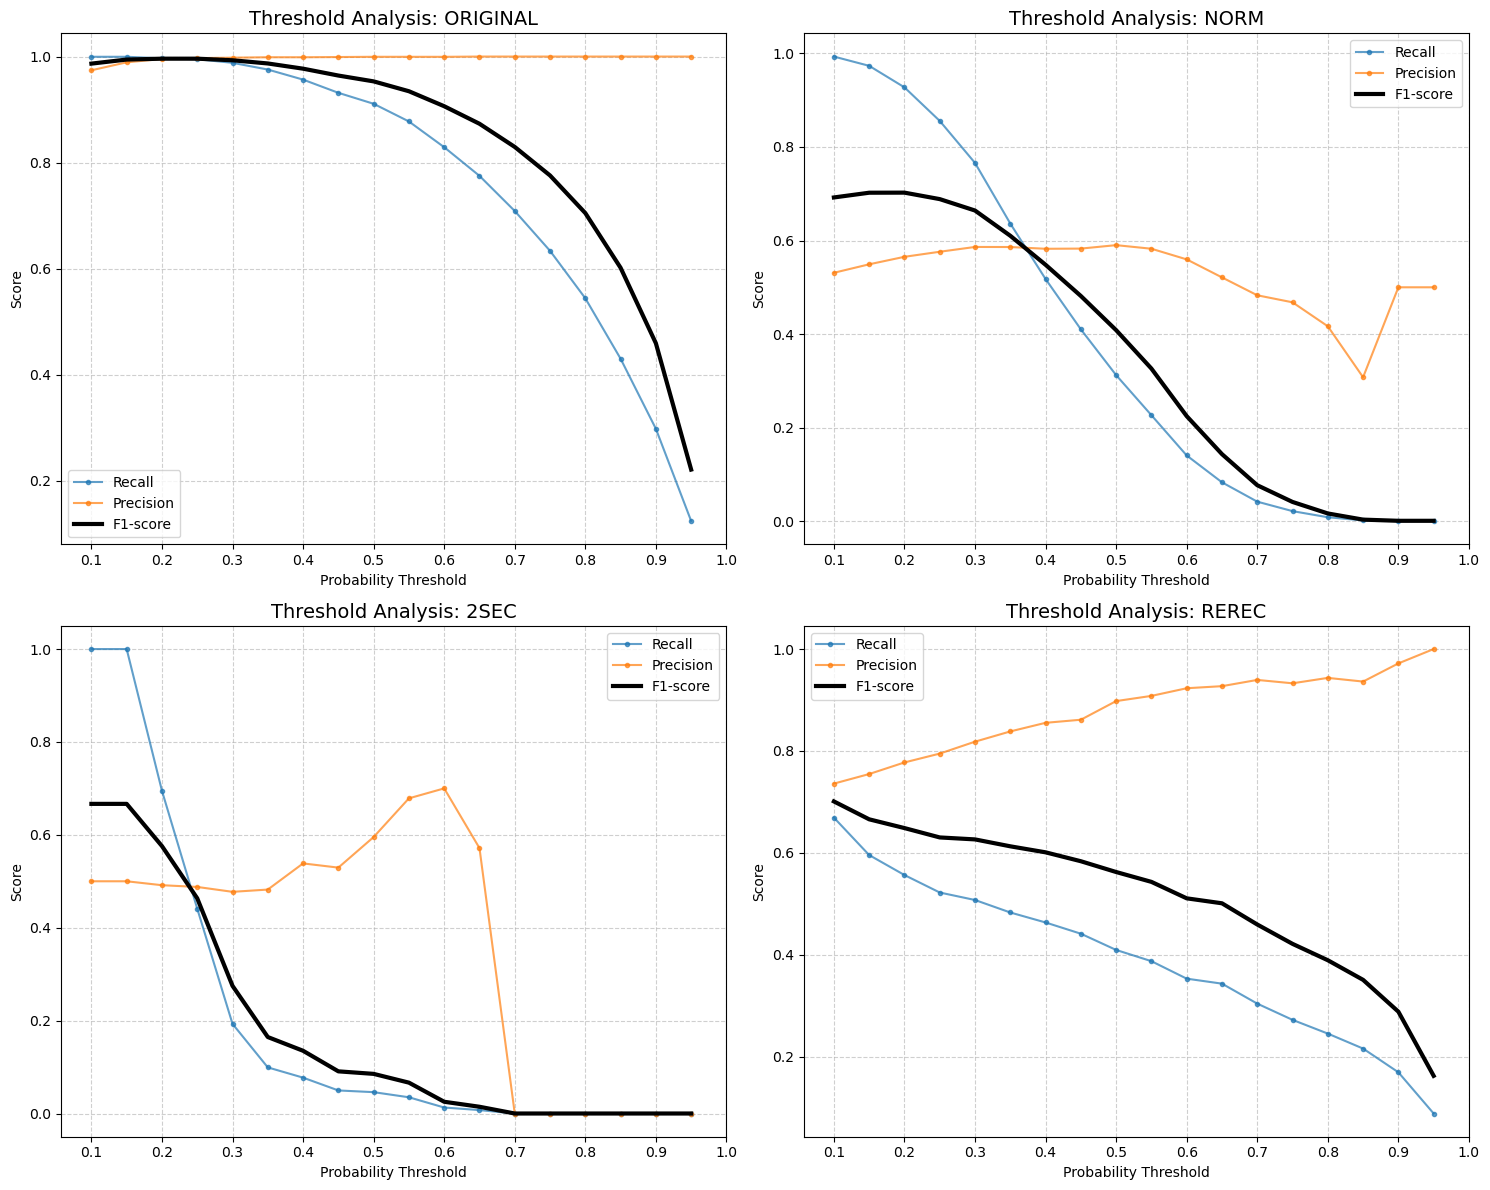

In [217]:
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = xgb_best_params[name]
    
    # Инициализация и обучение модели
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
            # Если вероятность > threshold, то 1, иначе 0
            y_pred_custom = (y_score > threshold).astype(int)
            
            recall_scores.append(metrics.recall_score(y_test, y_pred_custom, zero_division=0))
            precision_scores.append(metrics.precision_score(y_test, y_pred_custom, zero_division=0))
            f1_scores.append(metrics.f1_score(y_test, y_pred_custom, zero_division=0))

    # 5. Визуализация на i-м графике
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') # Выделим F1 пожирнее

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) # Сетка чуть пореже для читаемости
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()

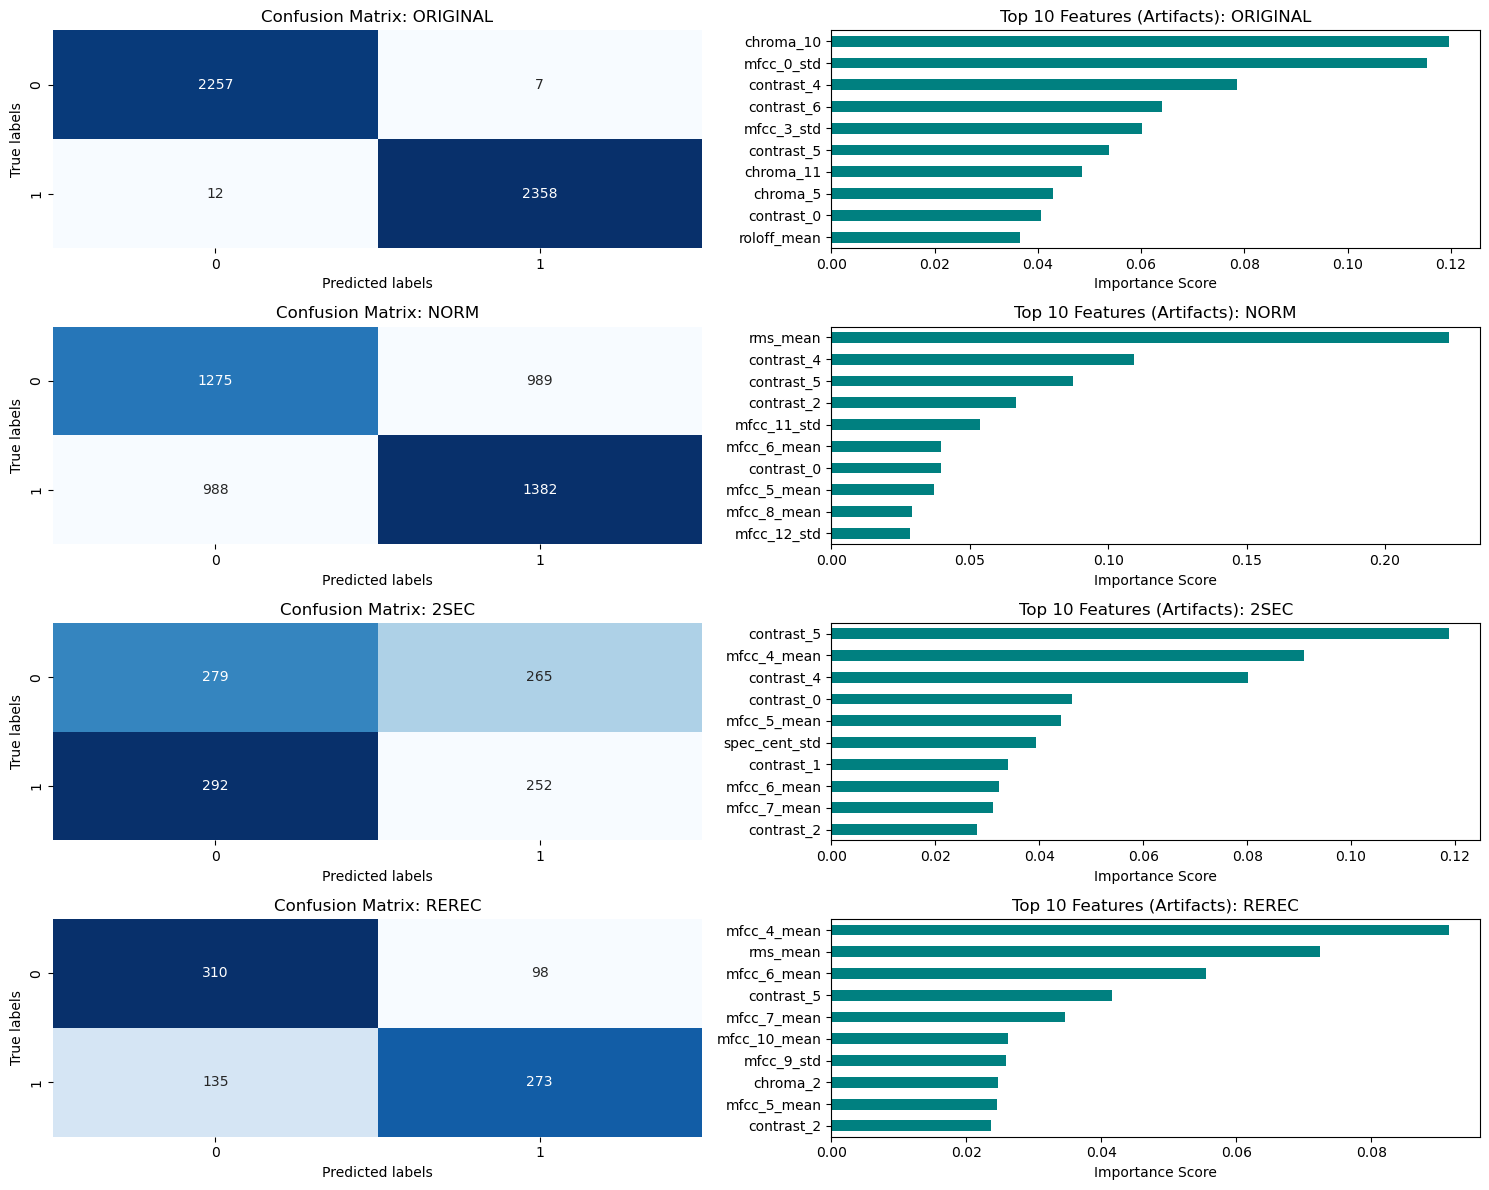


--- Итоговые результаты по всем датасетам ---
    Dataset       EER  Accuracy  F1-Score  Precision    Recall
0  original  0.003975  0.995900  0.995987   0.997040  0.994937
1      norm  0.428445  0.573371  0.582999   0.582876  0.583122
2      2sec  0.514706  0.488051  0.475024   0.487427  0.463235
3     rerec  0.294118  0.714461  0.700899   0.735849  0.669118


In [221]:
final_metrics = []

custom_thresholds = {
      'original': 0.25,
      'norm': 0.37,
      '2sec': 0.24,
      'rerec': 0.1, 
}

fig, axes = plt.subplots(4,2, figsize=(15,12))
# axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = xgb_best_params[name]
    
    # Инициализация и обучение модели
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i, 0], cmap='Blues', cbar=False)
    axes[i, 0].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i, 0].set_xlabel('Predicted labels')
    axes[i, 0].set_ylabel('True labels')

    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[i, 1], color='teal')
    axes[i, 1].set_title(f"Top 10 Features (Artifacts): {name.upper()}", fontsize=12)
    axes[i, 1].set_xlabel('Importance Score')

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
df_results.to_excel('results/research1_xgb_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)

In [10]:
knn_best_params = {
    'original': {
        'n_neighbors': 6,
        'weights': 'distance',
        'leaf_size': 36,
        'p': 1,
    },
    'norm': {
        'n_neighbors': 5,
        'weights': 'distance',
        'leaf_size': 13,
        'p': 1,
    },
    '2sec': {
        'n_neighbors': 57,
        'weights': 'distance',
        'leaf_size': 44,
        'p': 2,
    },
    'rerec': {
        'n_neighbors': 45,
        'weights': 'distance',
        'leaf_size': 17,
        'p': 1,
    },
}

KeyboardInterrupt: 

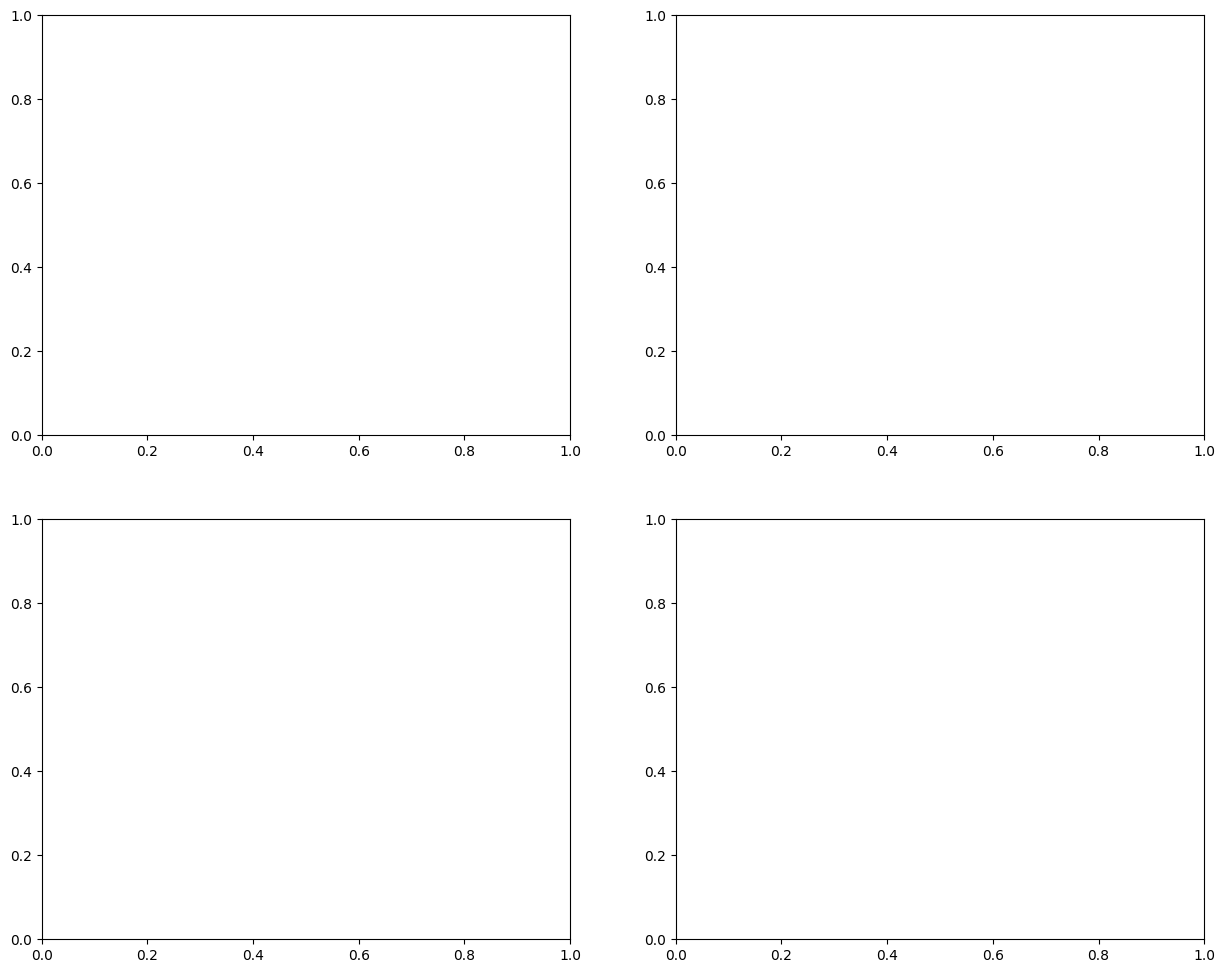

In [14]:
from sklearn.feature_selection import SequentialFeatureSelector
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = knn_best_params[name]
    
    # Инициализация и обучение модели
    model = SequentialFeatureSelector(
          neighbors.KNeighborsClassifier(**params, n_jobs=-1),
          n_features_to_select=3,
          direction='backward',
          scoring='accuracy'
    )
    # model = neighbors.KNeighborsClassifier(**params, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
            # Если вероятность > threshold, то 1, иначе 0
            y_pred_custom = (y_score > threshold).astype(int)
            
            recall_scores.append(metrics.recall_score(y_test, y_pred_custom))
            precision_scores.append(metrics.precision_score(y_test, y_pred_custom))
            f1_scores.append(metrics.f1_score(y_test, y_pred_custom))

    # Визуализация 
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') 

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) 
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()

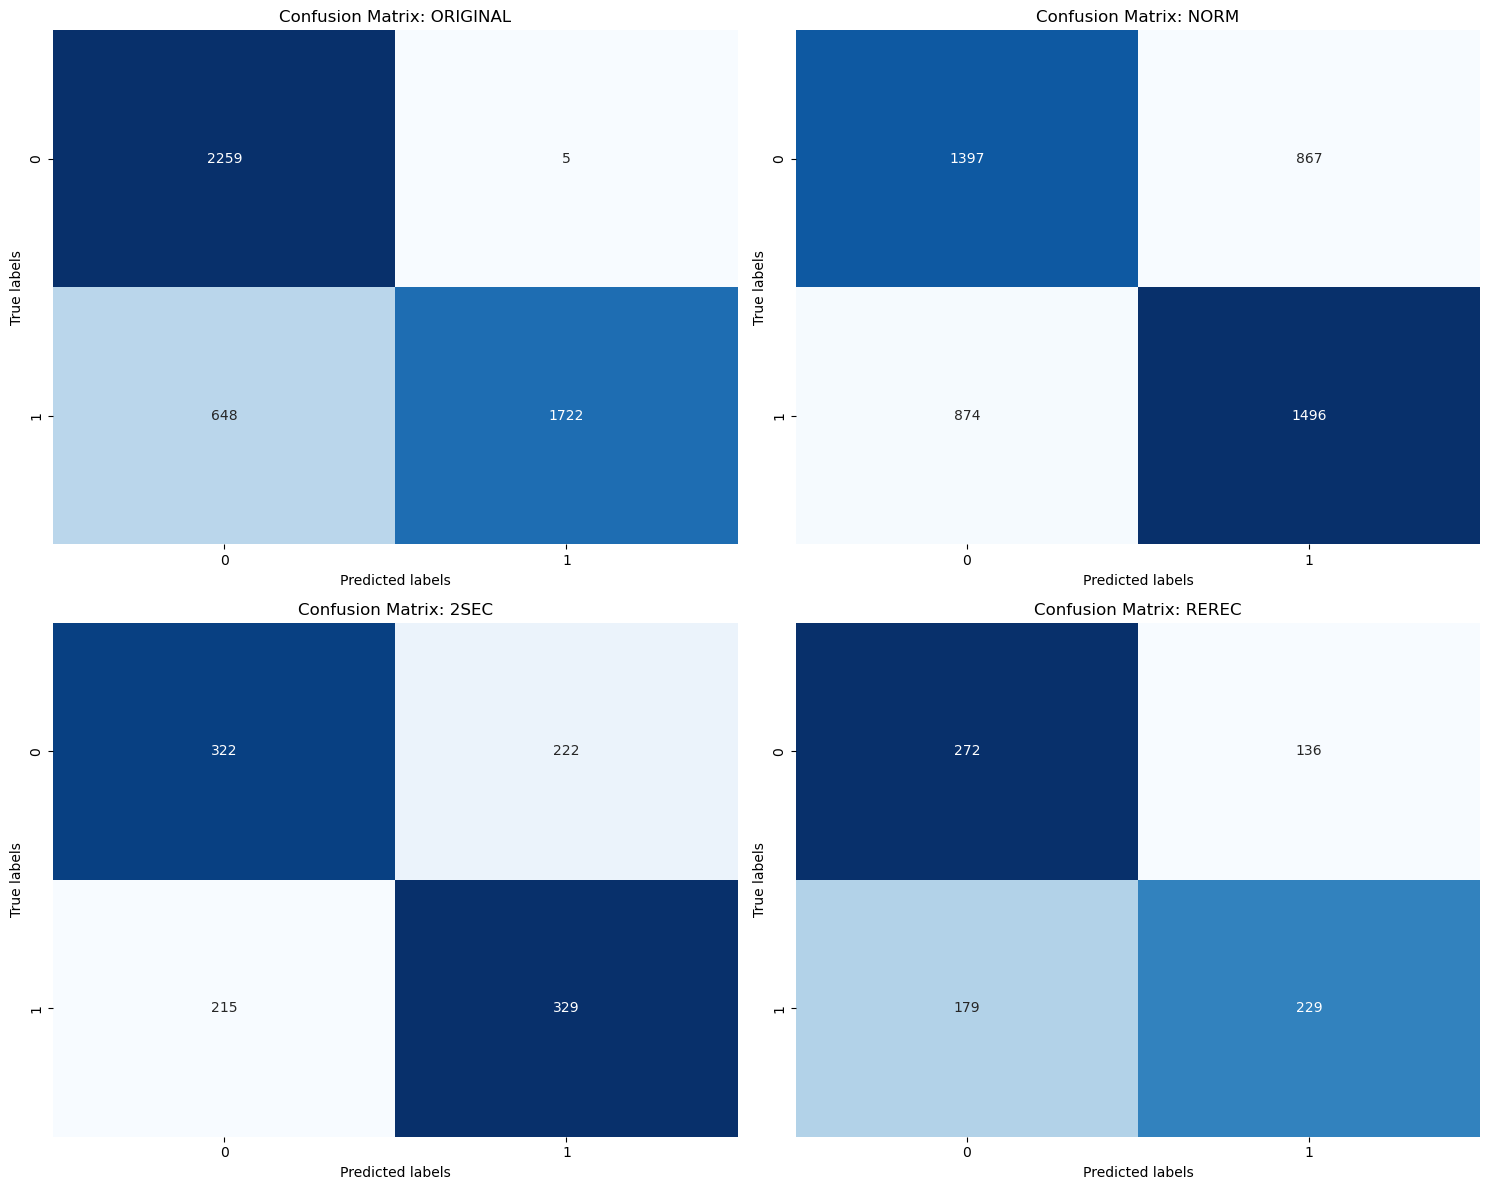


--- Итоговые результаты по всем датасетам ---
    Dataset       EER  Accuracy  F1-Score  Precision    Recall
0  original  0.032686  0.859085  0.840615   0.997105  0.726582
1      norm  0.374262  0.624299  0.632157   0.633094  0.631224
2      2sec  0.402574  0.598346  0.600913   0.597096  0.604779
3     rerec  0.392157  0.613971  0.592497   0.627397  0.561275


In [236]:
final_metrics = []

custom_thresholds = {
      'original': 0.55,
      'norm': 0.4,
      '2sec': 0.56,
      'rerec': 0.67, 
}

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = knn_best_params[name]
    
    # Инициализация и обучение модели
    model = neighbors.KNeighborsClassifier(**params, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i].set_xlabel('Predicted labels')
    axes[i].set_ylabel('True labels')

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
df_results.to_excel('results/research1_knn_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)